In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import defaultdict
import json
import sys
import pickle
# Add parent directories to path to import project modules
curr_dir = os.path.dirname(os.getcwd())
project_root = os.path.abspath(os.path.join(curr_dir, os.pardir))
sys.path.append(project_root)
print(f"Added project root to sys.path: {project_root}")
from snnTorch.generalization_madrid.process_signal import load_experimental_data, spikify_signal


Added project root to sys.path: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples


# Load Data

In [5]:

session= "2025-09-25_16-41-14"
data_path=r"C:\Madrid_tests"
spikes_dir=os.path.join(os.getcwd(), "spikes")
print(f"Spikes directory: {spikes_dir}")
network="updnb4ds_100_7"
adapt=20
spikes_path=os.path.join(spikes_dir,network, f"{network}_adapt{adapt}_spikes.pkl" if adapt else f"{network}_spikes.pkl")

Spikes directory: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\spikes


In [6]:
"""
    Plots signal, ground truth ripples, and detected spikes for a single channel.
    """
    # Load Output Spikes
with open(spikes_path, 'rb') as f:
    all_spikes = pickle.load(f)

# Handle case where pickle might be keyed by session or just be the data
if session in all_spikes:
    session_data = all_spikes[session]
else:
    print(f"Session {session} not found in pickle keys: {list(all_spikes.keys())[:5]}...")

channel = session_data.get('channel', None)

output_spikes_ms = np.array(session_data['spikes'])
output_spikes_sec = output_spikes_ms / 1000.0

# Load Signal and GT
try:
    signal, ripples_samples = load_experimental_data(
        data_path, session, channel=channel, load_data=True, verbose=False
    )
except Exception as e:
    print(f"Error loading data: {e}")

if signal is None:
    print("Could not load signal.")

fs = 30000 
time = np.arange(len(signal)) / fs

if ripples_samples is not None and len(ripples_samples) > 0:
    gt_sec = ripples_samples / fs
else:
    gt_sec = np.empty((0, 2))

Starting from 0 :D
Annotation for session 2025-09-25_16-41-14 not found in C:\Madrid_tests\annotations\HFO_Events.
C:\Madrid_tests\annotations\Ripple_Events\events_2025-09-25_16-41-14\events
Light stim file not found: C:\Madrid_tests\annotations\Ripple_Events\events_2025-09-25_16-41-14\events\events_light.txt not found.
⚠️ TTL signal not detected or too low amplitude.
Loaded 144 ground truth ripple events.
Loaded 331 SNN predicted ripple events.
⚠️ No light stimulation events loaded.


# Crop Window

In [15]:
# Params
window=(100,150)  # (start_sec, end_sec) or None for full signal
tolerance=0.02  # seconds
max_detection_offset=0.12  # seconds
fp_grouping_window=0.1,
extra_tolerance=0.1,

In [16]:
# Windowing
if window is not None:
    w_start, w_end = window
    mask = (time >= w_start) & (time <= w_end)
    time_plot = time[mask]
    signal_plot = signal[mask]
    
    # Filter spikes for plotting
    spikes_plot = output_spikes_sec[(output_spikes_sec >= w_start) & (output_spikes_sec <= w_end)]
    
    # Filter GT for plotting
    gt_mask = (gt_sec[:, 1] >= w_start) & (gt_sec[:, 0] <= w_end)
    gt_plot = gt_sec[gt_mask]
else:
    w_start, w_end = 0, time[-1]
    time_plot = time
    signal_plot = signal
    spikes_plot = output_spikes_sec
    gt_plot = gt_sec

# Classification Logic (Global, to determine TP/FP correctly even near window edges)
classified_spikes = [] # List of (label, time)

# Sort spikes
sorted_spikes = np.sort(output_spikes_sec)

# Define valid windows for TPs
valid_windows = []
for start, end in gt_sec:
    valid_windows.append((start - tolerance, start + max_detection_offset))
    
used_gt_indices = set()
used_spike_indices = set()
# 1. Find TPs
for r_idx, (v_start, v_end) in enumerate(valid_windows):
    # Find spikes in this window
    in_window_idxs = np.where((sorted_spikes >= v_start) & (sorted_spikes <= v_end))[0]
    
    if len(in_window_idxs) > 0:
        # First spike is the detection
        first_idx = in_window_idxs[0]
        classified_spikes.append(('TP', sorted_spikes[first_idx]))
        used_spike_indices.add(first_idx)
        used_gt_indices.add(r_idx)
            
        # Mark others as used (part of TP event)
        for idx in in_window_idxs:
            used_spike_indices.add(idx)


# 2. Find FPs
current_fp_end = -np.inf
for i, spk in enumerate(sorted_spikes):
    if i in used_spike_indices:
        continue
        
    # Check if in ANY valid window (to avoid counting late spikes in a ripple as FP)
    is_in_valid = False
    for v_start, v_end in valid_windows:
            if v_start <= spk <= v_end+extra_tolerance:
                is_in_valid = True
                break
    
    if is_in_valid:
        continue
        
    # It's an FP
    if spk > current_fp_end:
        classified_spikes.append(('FP', spk))
        current_fp_end = spk + fp_grouping_window

In [17]:
def plot_window(plot_input_spikes=False, filename=None, show=True):
    # Plotting
    fig, ax = plt.subplots(figsize=(15, 5))
    
    ax.plot(time_plot, signal_plot, color='black', alpha=0.6, linewidth=0.8, label='LFP')
    
    y_min, y_max = np.min(signal_plot), np.max(signal_plot)
    yrange = y_max - y_min

    # Plot All Output Spikes (Scatter)
    ax.scatter(spikes_plot, [y_min*0.3]*len(spikes_plot), color='purple', marker='.', s=30, label='All Spikes', zorder=3)
    print (len(spikes_plot), "output spikes in window")
    # Plot Input Spikes if requested
    if plot_input_spikes:
        try:
            # Generate input spikes using spikify_signal
            # Using default parameters: adapt_threshold=True, factor=30 (1000Hz)
            adapt_threshold=True if adapt > 0 else False
            time_max=adapt if adapt > 0 else 120
            spikified, _ = spikify_signal(signal, fs=fs, adapt_threshold=adapt_threshold, time_max=time_max, factor=30,refractory=0.0003, verbose=False)
            
            fs_spikes = fs / 30
            time_spikes = np.arange(len(spikified)) / fs_spikes
            
            # Windowing for spikes
            if window:
                mask_spikes = (time_spikes >= w_start) & (time_spikes <= w_end)
                spikes_plot_input = spikified[mask_spikes]
                time_spikes_plot = time_spikes[mask_spikes]
            else:
                spikes_plot_input = spikified
                time_spikes_plot = time_spikes

            # UP spikes (col 0)
            up_indices = np.where(spikes_plot_input[:, 0] == 1)[0]
            up_times = time_spikes_plot[up_indices]
            
            # DOWN spikes (col 1)
            down_indices = np.where(spikes_plot_input[:, 1] == 1)[0]
            down_times = time_spikes_plot[down_indices]
            
            # Determine height for spikes
            spike_height = yrange * 0.15
            
            # Plot UP spikes at top
            ax.vlines(up_times, y_max - spike_height, y_max, color='red', alpha=0.3, linewidth=0.5, label='Input UP')
            
            # Plot DOWN spikes at bottom
            ax.vlines(down_times, y_min, y_min + spike_height, color='blue', alpha=0.3, linewidth=0.5, label='Input DOWN')
            
            # Adjust ylim to include spikes
            # y_max = y_max + spike_height
            # y_min = y_min - spike_height
            
        except Exception as e:
            print(f"Error generating/plotting input spikes: {e}")
    
    # Plot GT Ripples
    for idx, (start, end) in enumerate(gt_plot):
        # Find original index to check if detected
        orig_idx = -1
        for k, (s, e) in enumerate(gt_sec):
            if np.isclose(s, start) and np.isclose(e, end):
                orig_idx = k
                break
        
        is_detected = orig_idx in used_gt_indices
        
        rect = Rectangle((start, y_min), end-start, yrange, alpha=0.3, color='yellow', label='GT Ripple' if idx==0 else None)
        ax.add_patch(rect)
        
        if not is_detected:
             ax.axvline(x=(start+end)/2, color='blue', linestyle='--', alpha=0.5, label='FN' if idx==0 else None)

    # Plot Spikes
    for label, t in classified_spikes:
        if t < w_start or t > w_end:
            continue
            
        color = 'green' if label == 'TP' else 'red'
        ax.axvline(x=t, color=color, linestyle='-', linewidth=1.5, label=label if label not in ax.get_legend_handles_labels()[1] else None)
        
        if label == 'FP':
             ax.add_patch(Rectangle((t, y_min), 0.05, yrange, alpha=0.1, color='red'))

    # Calculate and Print Metrics
    tp_count = len(used_gt_indices)
    fn_count = len(gt_sec) - tp_count
    fp_count = sum(1 for label, _ in classified_spikes if label == 'FP')

    precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0
    recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n--- Metrics for Session {session} Ch {channel} ---")
    print(f"TP: {tp_count} | FP: {fp_count} | FN: {fn_count}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("------------------------------------------------")

    ax.set_xlim(w_start, w_end)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Session {session} Ch {channel}")
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300)
    
    if show:
        plt.show()
    else:
        plt.close()
    return fig,ax

72 output spikes in window

--- Metrics for Session 2025-09-25_16-41-14 Ch 21 ---
TP: 107 | FP: 93 | FN: 37
Precision: 0.5350
Recall:    0.7431
F1 Score:  0.6221
------------------------------------------------


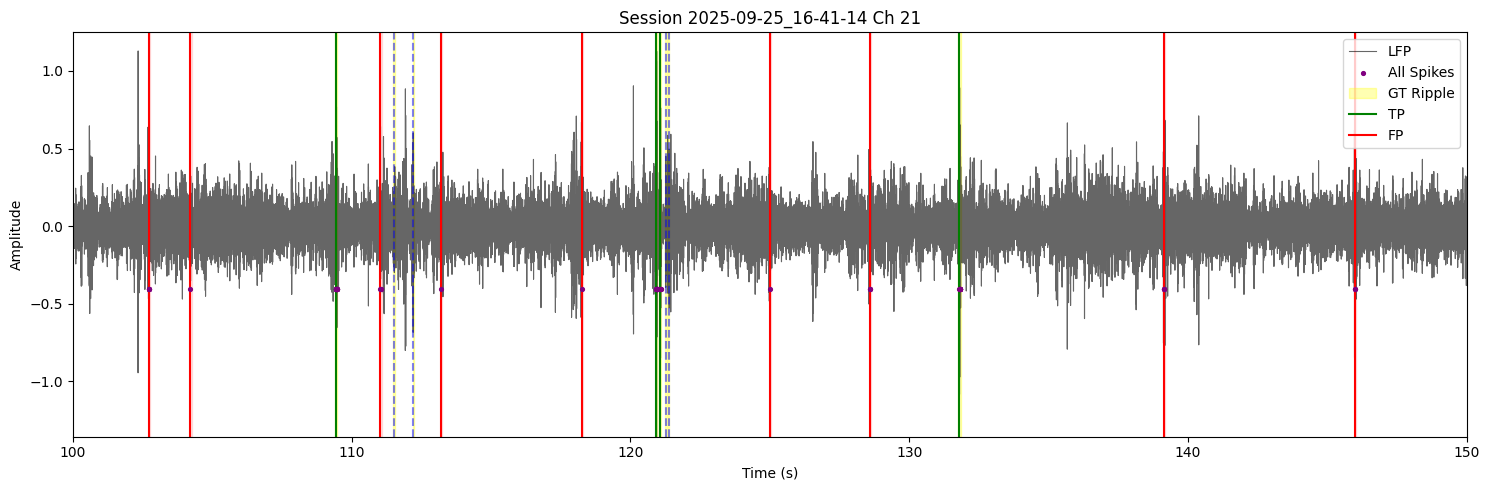

In [18]:
fig,ax=plot_window(plot_input_spikes=False,)